<a href="https://colab.research.google.com/github/nur21horin/machine_learning/blob/main/End_to_End_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [36]:
df = pd.read_csv("/content/daraz_shoes_data.csv")

In [37]:
print("--- 1.1 First 5 Rows (Head) ---")
print(df.head())

print("\n--- 1.2 Last 5 Rows (Tail) ---")
print(df.tail())

print("\n--- 1.3 Dataset Summary Info ---")
print(df.info())

print("Describe")
print(df.describe())

print("\n--- 1.4 Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


--- 1.1 First 5 Rows (Head) ---
                                               title  ...         Nid
0  Loafer ,Eid Collection Flat Casual Half Shoe L...  ...   347031153
1  Versatile -Hot Collection Stylish and Fashiona...  ...   392124662
2  MARVEL FASHIONS NEW  Fashionable Half Shoe For...  ...   347652839
3  New Brown Color Artificial Leather Loafer Shoe...  ...  1573426420
4  FASHION 2024 Black Blue Grey And Cream Color C...  ...   431224029

[5 rows x 10 columns]

--- 1.2 Last 5 Rows (Tail) ---
                                                 title  ...        Nid
195  Indispensable-Quality And Durability-Stylish B...  ...  349274051
196  Punjabi half loafers artificial soft leather s...  ...  182613294
197  2025 New Trendy Black And Grey Color SAMBA Can...  ...  525043590
198  Fashion Leadther Slip On Mens Driving Moccasin...  ...  314754572
199  New Fashionable Velvet Half Shoe For Men Black...  ...  316552084

[5 rows x 10 columns]

--- 1.3 Dataset Summary Info ---
<class 'pa

In [38]:
print("NUll counts per column before fix:")
df.isnull().sum()

NUll counts per column before fix:


,0
title,0
productUrl,0
imageUrl,0
price,0
rating,59
review,57
brandName,5
SellerId,0
category,0
Nid,0


In [39]:
# Fill numerical nulls with median, categorical with mode
df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

print(f"Total Nulls Remaining: {df.isnull().sum().sum()}")

print("\n--- 2.2 Handling Duplicate Rows ---")
print(f"Duplicate rows found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

print("\n--- 2.3 Handling Outliers (IQR Capping on BMI) ---")
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q1 - Q3
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR




KeyError: 'age'

In [17]:
df['bmi'] = np.where(df['bmi'] > upper_bound, upper_bound, df['bmi'])
df['bmi'] = np.where(df['bmi'] < lower_bound, lower_bound, df['bmi'])
print("Outliers in 'bmi' have been capped.")

Outliers in 'bmi' have been capped.


In [18]:
print("\n--- 3.1 Encoding Categorical Text Columns ---")
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'].astype(str))
df['smoker'] = le_smoker.fit_transform(df['smoker'].astype(str))
df['region'] = le_region.fit_transform(df['region'].astype(str))

print("Encoded sample data:")
print(df[['sex', 'smoker', 'region']].head())


--- 3.1 Encoding Categorical Text Columns ---
Encoded sample data:
   sex  smoker  region
0    0       1       3
1    1       0       2
2    1       0       2
3    1       0       1
4    1       0       1



--- 4.1 Generating Visualizations ---


/tmp/ipykernel_505/2844202933.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=le_smoker.inverse_transform(df['smoker']), ax=axes[0, 1], palette='pastel')


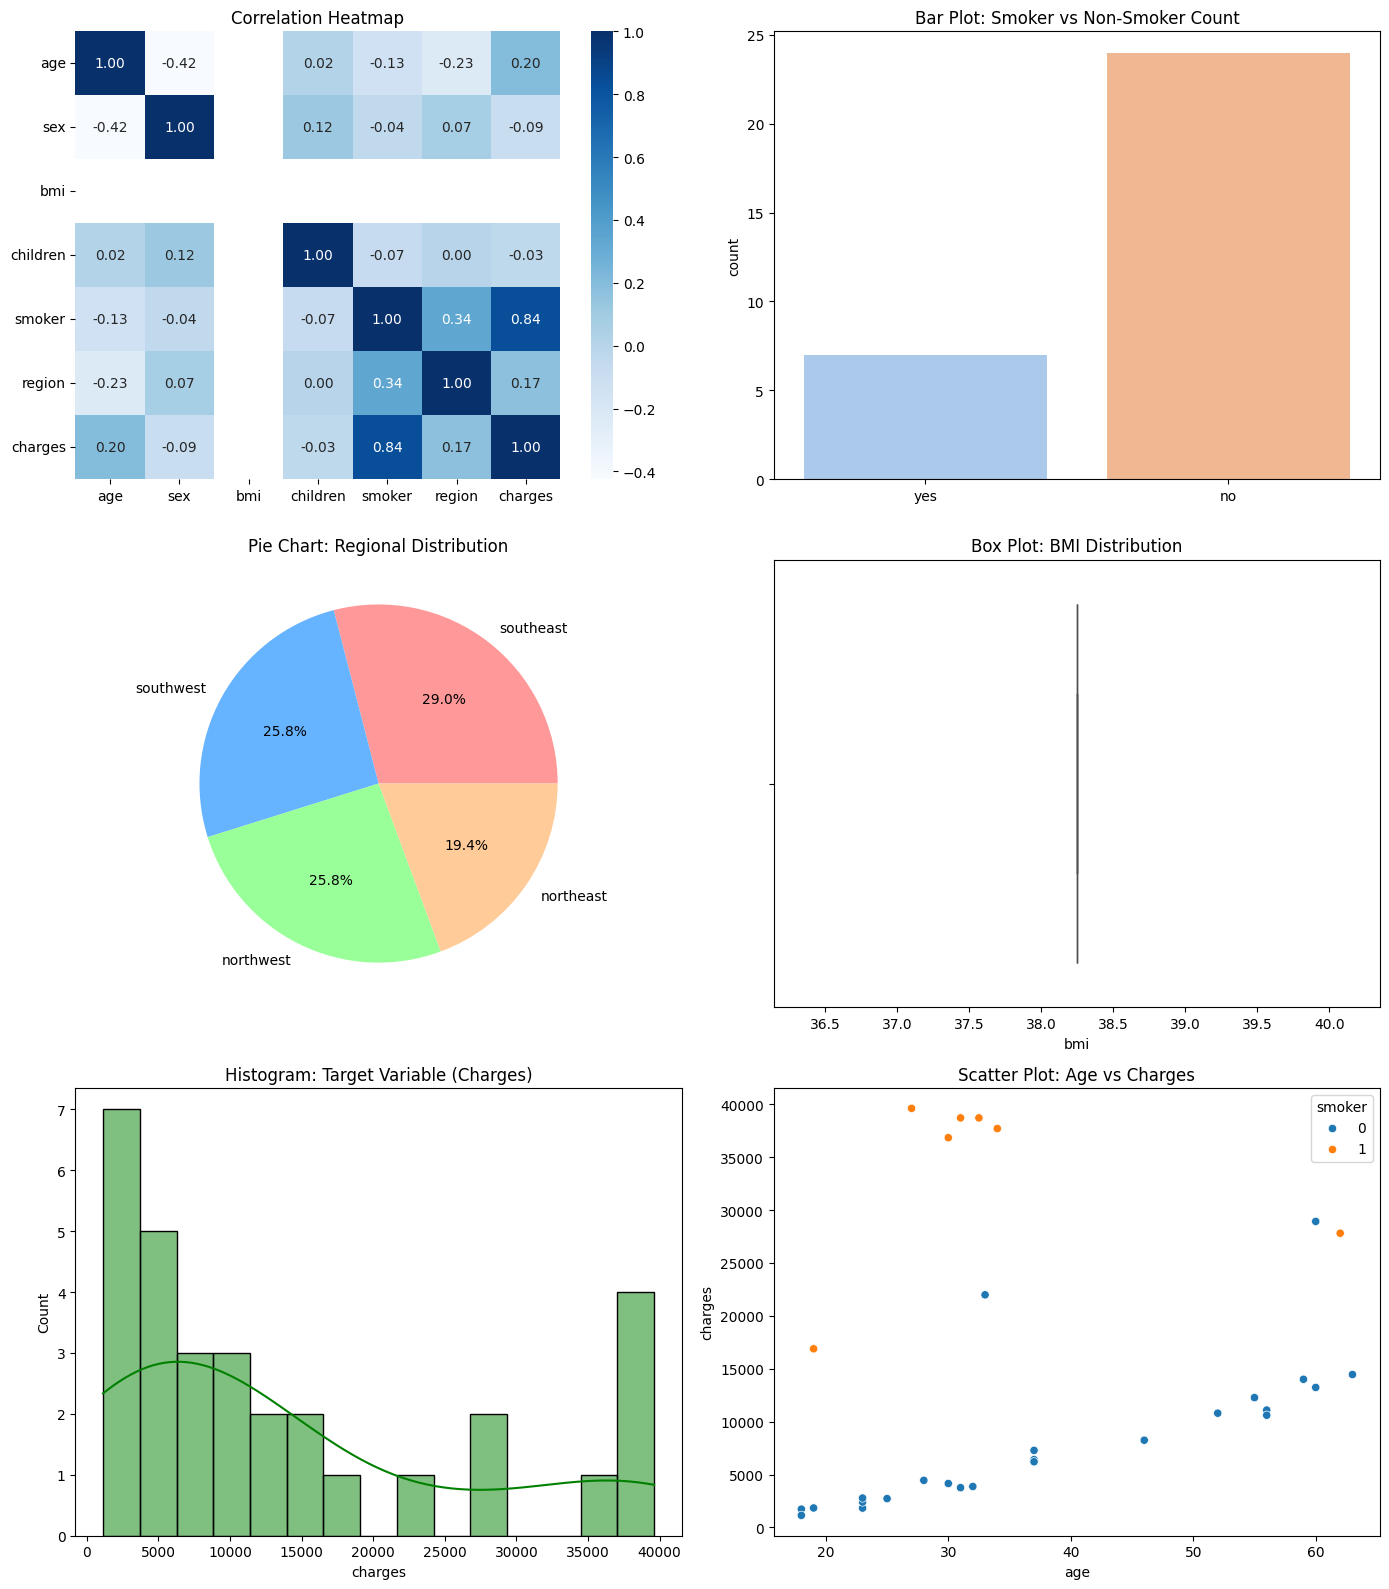

In [19]:
# ==========================================
# 4. DATA VISUALIZATION
# ==========================================
print("\n--- 4.1 Generating Visualizations ---")
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# Heatmap (Correlation Matrix)
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title('Correlation Heatmap')

# Bar Plot
sns.countplot(x=le_smoker.inverse_transform(df['smoker']), ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Bar Plot: Smoker vs Non-Smoker Count')

# Pie Chart
region_counts = df['region'].value_counts()
axes[1, 0].pie(region_counts, labels=le_region.inverse_transform(region_counts.index), autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 0].set_title('Pie Chart: Regional Distribution')

# Box Plot
sns.boxplot(x=df['bmi'], ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Box Plot: BMI Distribution')

# Histogram
sns.histplot(df['charges'], bins=15, kde=True, ax=axes[2, 0], color='green')
axes[2, 0].set_title('Histogram: Target Variable (Charges)')

# Scatter Plot
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axes[2, 1])
axes[2, 1].set_title('Scatter Plot: Age vs Charges')

plt.tight_layout()
plt.show()

In [35]:
# ==========================================
# 5. LINEAR REGRESSION MODEING
# ==========================================
# Define target variable
Y = df['charges']

# ---- 5.1 Single Linear Regression (Using 'age') ----
print("\n=== RUNNING SINGLE LINEAR REGRESSION ===")
X_single = df[['age']]
X_train_s, X_test_s, Y_train_s, Y_test_s = train_test_split(X_single, Y, test_size=0.2, random_state=42)

single_model = LinearRegression()
single_model.fit(X_train_s, Y_train_s)
Y_pred_s = single_model.predict(X_test_s)

print(f"Single LR R2 Score (Accuracy): {r2_score(Y_test_s, Y_pred_s):.4f}")
print(f"Single LR Mean Absolute Error: {mean_absolute_error(Y_test_s, Y_pred_s):.2f}")

# ---- 5.2 Multiple Linear Regression (Using all features) ----
print("\n=== RUNNING MULTIPLE LINEAR REGRESSION ===")
X_multi = df.drop(columns=['charges'])
X_train_m, X_test_m, Y_train_m, Y_test_m = train_test_split(X_multi, Y, test_size=0.2, random_state=42)

# Scale features for Multiple Regression
scaler = StandardScaler()
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

multi_model = LinearRegression()
multi_model.fit(X_train_m_scaled, Y_train_m)
Y_pred_m = multi_model.predict(X_test_m_scaled)

print(f"Multiple LR R2 Score (Accuracy): {r2_score(Y_test_m, Y_pred_m):.4f}")
print(f"Multiple LR Mean Absolute Error: {mean_absolute_error(Y_test_m, Y_pred_m):.2f}")


=== RUNNING SINGLE LINEAR REGRESSION ===
Single LR R2 Score (Accuracy): -0.0771
Single LR Mean Absolute Error: 13027.80

=== RUNNING MULTIPLE LINEAR REGRESSION ===
Multiple LR R2 Score (Accuracy): 0.6722
Multiple LR Mean Absolute Error: 7132.55


In [31]:
import numpy as np
import pandas as pd
import joblib

In [32]:
# ==========================================
# 6. MODEL SAVE
# ==========================================
print("\n--- 6.1 Saving trained files to disk ---")
joblib.dump(multi_model, 'insurance_lr_model.pkl')
joblib.dump(scaler, 'insurance_scaler.pkl')
print("Saved 'insurance_lr_model.pkl' and 'insurance_scaler.pkl' successfully!")


--- 6.1 Saving trained files to disk ---
Saved 'insurance_lr_model.pkl' and 'insurance_scaler.pkl' successfully!


In [33]:
# ==========================================
# STEP 2: LOAD THE SAVED MODEL & SCALER
# ==========================================
print("--- 2.1 Loading Saved Model and Scaler ---")
try:
    loaded_model = joblib.load('insurance_lr_model.pkl')
    loaded_scaler = joblib.load('insurance_scaler.pkl')
    print("Successfully loaded 'insurance_lr_model.pkl' and 'insurance_scaler.pkl'!")
except FileNotFoundError:
    print("Error: Please make sure 'insurance_lr_model.pkl' and 'insurance_scaler.pkl' are uploaded to your Colab files panel.")

--- 2.1 Loading Saved Model and Scaler ---
Successfully loaded 'insurance_lr_model.pkl' and 'insurance_scaler.pkl'!


In [34]:
# ==========================================
# STEP 3: DEFINE NEW VARIABLE DATA
# ==========================================
print("\n--- 3.1 Creating New Customer Data for Prediction ---")

# Let's create a DataFrame mimicking 3 brand new customers.
# Features MUST be in the exact same order as the training data:
# [age, sex, bmi, children, smoker, region]
# Note: Categorical features must use the same encoded numerical format:
# sex: female=0, male=1 | smoker: no=0, yes=1 | region: northwest=1, southeast=2, southwest=3, etc.

new_customers = pd.DataFrame([
    {
        'age': 25,
        'sex': 1,       # male
        'bmi': 24.2,    # Normal BMI
        'children': 0,
        'smoker': 0,    # Non-smoker
        'region': 3     # southwest
    },
    {
        'age': 45,
        'sex': 0,       # female
        'bmi': 36.5,    # High BMI (Obese range)
        'children': 2,
        'smoker': 1,    # Smoker
        'region': 2     # southeast
    },
    {
        'age': 62,
        'sex': 0,       # female
        'bmi': 28.1,    # Overweight BMI
        'children': 1,
        'smoker': 0,    # Non-smoker
        'region': 1     # northwest
    }
])

print("New customer input profiles:")
print(new_customers)


--- 3.1 Creating New Customer Data for Prediction ---
New customer input profiles:
   age  sex   bmi  children  smoker  region
0   25    1  24.2         0       0       3
1   45    0  36.5         2       1       2
2   62    0  28.1         1       0       1


In [24]:
# ==========================================
# STEP 4: PREPROCESS & SCALE NEW DATA
# ==========================================
print("\n--- 4.1 Scaling New Input Variables ---")
# Multiple Linear Regression relies heavily on the exact scale established during training.
# We use .transform() instead of .fit_transform() so we don't recalculate the weights.
new_customers_scaled = loaded_scaler.transform(new_customers)


--- 4.1 Scaling New Input Variables ---


In [25]:
# ==========================================
# STEP 5: PREDICT USING THE LOADED MODEL
# ==========================================
print("\n--- 5.1 Making Predictions ---")
predicted_charges = loaded_model.predict(new_customers_scaled)

# Add the predictions back into our dataframe for clear reporting
new_customers['Predicted_Charges ($)'] = np.round(predicted_charges, 2)

# Print final readable output
print("\n===========================================")
print("          FINAL PREDICTION RESULTS         ")
print("===========================================")
print(new_customers)


--- 5.1 Making Predictions ---

          FINAL PREDICTION RESULTS         
   age  sex   bmi  children  smoker  region  Predicted_Charges ($)
0   25    1  24.2         0       0       3                4524.27
1   45    0  36.5         2       1       2               33305.58
2   62    0  28.1         1       0       1               12627.68
